# Read local image dataset

### Examples
- https://images.cv/data-sources/animal-image-dataset

In [20]:
# %pip install datasets fastai

### Download a local dataset

In [3]:
# !curl -L -o dataset/animal-image-dataset-90-different-animals.zip https://www.kaggle.com/api/v1/datasets/download/iamsouravbanerjee/animal-image-dataset-90-different-animals

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  656M  100  656M    0     0  34.4M      0  0:00:19  0:00:19 --:--:-- 36.9M


In [5]:
# !unzip dataset/animal-image-dataset-90-different-animals.zip -d dataset

In [6]:
# # Move contents from nested animals/animals to animals
# !mv dataset/animals/animals/* dataset/animals/

# # Remove the now-empty nested folder
# !rmdir dataset/animals/animals

### Load a local dataset

In [1]:
from collections import Counter
from datasets import load_dataset

In [3]:
image_dir = 'dataset/animals'
dataset = load_dataset("imagefolder", data_dir=image_dir)

Resolving data files:   0%|          | 0/5400 [00:00<?, ?it/s]

In [9]:
# Check out what's inside
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5400
    })
})

In [10]:
label_column="label"
dataset['train'].features[label_column].names

['antelope',
 'badger',
 'bat',
 'bear',
 'bee',
 'beetle',
 'bison',
 'boar',
 'butterfly',
 'cat',
 'caterpillar',
 'chimpanzee',
 'cockroach',
 'cow',
 'coyote',
 'crab',
 'crow',
 'deer',
 'dog',
 'dolphin',
 'donkey',
 'dragonfly',
 'duck',
 'eagle',
 'elephant',
 'flamingo',
 'fly',
 'fox',
 'goat',
 'goldfish',
 'goose',
 'gorilla',
 'grasshopper',
 'hamster',
 'hare',
 'hedgehog',
 'hippopotamus',
 'hornbill',
 'horse',
 'hummingbird',
 'hyena',
 'jellyfish',
 'kangaroo',
 'koala',
 'ladybugs',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'mosquito',
 'moth',
 'mouse',
 'octopus',
 'okapi',
 'orangutan',
 'otter',
 'owl',
 'ox',
 'oyster',
 'panda',
 'parrot',
 'pelecaniformes',
 'penguin',
 'pig',
 'pigeon',
 'porcupine',
 'possum',
 'raccoon',
 'rat',
 'reindeer',
 'rhinoceros',
 'sandpiper',
 'seahorse',
 'seal',
 'shark',
 'sheep',
 'snake',
 'sparrow',
 'squid',
 'squirrel',
 'starfish',
 'swan',
 'tiger',
 'turkey',
 'turtle',
 'whale',
 'wolf',
 'wombat',
 'woodpecker',


In [11]:
# Get the labels from the dataset
labels = dataset['train'][label_column]

# Count the number of samples for each label
label_counts = Counter(labels)

# Print the results
label_counts

Counter({0: 60,
         1: 60,
         2: 60,
         3: 60,
         4: 60,
         5: 60,
         6: 60,
         7: 60,
         8: 60,
         9: 60,
         10: 60,
         11: 60,
         12: 60,
         13: 60,
         14: 60,
         15: 60,
         16: 60,
         17: 60,
         18: 60,
         19: 60,
         20: 60,
         21: 60,
         22: 60,
         23: 60,
         24: 60,
         25: 60,
         26: 60,
         27: 60,
         28: 60,
         29: 60,
         30: 60,
         31: 60,
         32: 60,
         33: 60,
         34: 60,
         35: 60,
         36: 60,
         37: 60,
         38: 60,
         39: 60,
         40: 60,
         41: 60,
         42: 60,
         43: 60,
         44: 60,
         45: 60,
         46: 60,
         47: 60,
         48: 60,
         49: 60,
         50: 60,
         51: 60,
         52: 60,
         53: 60,
         54: 60,
         55: 60,
         56: 60,
         57: 60,
         58: 60,
       

#### split based on percent

In [40]:
# Split the training data into train and test (let's say 10% for the test set)
train_test_split = dataset['train'].train_test_split(test_size=0.1)

# Further split the training set to get a validation set (e.g., 10% of the training set)
train_val_split = train_test_split['train'].train_test_split(test_size=0.1)

# Combine the splits into a new DatasetDict
final_dataset = {
    'train': train_val_split['train'],
    'val': train_val_split['test'],
    'test': train_test_split['test']
}

final_dataset

{'train': Dataset({
     features: ['image', 'label'],
     num_rows: 4374
 }),
 'val': Dataset({
     features: ['image', 'label'],
     num_rows: 486
 }),
 'test': Dataset({
     features: ['image', 'label'],
     num_rows: 540
 })}

#### split based on samples

In [41]:
# Split the training data into train and test (let's say 1000 sample for the test set)
train_test_split = dataset['train'].train_test_split(test_size=1000)

# Further split the training set to get a validation set (e.g., 10% of the training set)
train_val_split = train_test_split['train'].train_test_split(test_size=0.1)

# Combine the splits into a new DatasetDict
final_dataset = {
    'train': train_val_split['train'],
    'val': train_val_split['test'],
    'test': train_test_split['test']
}

final_dataset

{'train': Dataset({
     features: ['image', 'label'],
     num_rows: 3960
 }),
 'val': Dataset({
     features: ['image', 'label'],
     num_rows: 440
 }),
 'test': Dataset({
     features: ['image', 'label'],
     num_rows: 1000
 })}

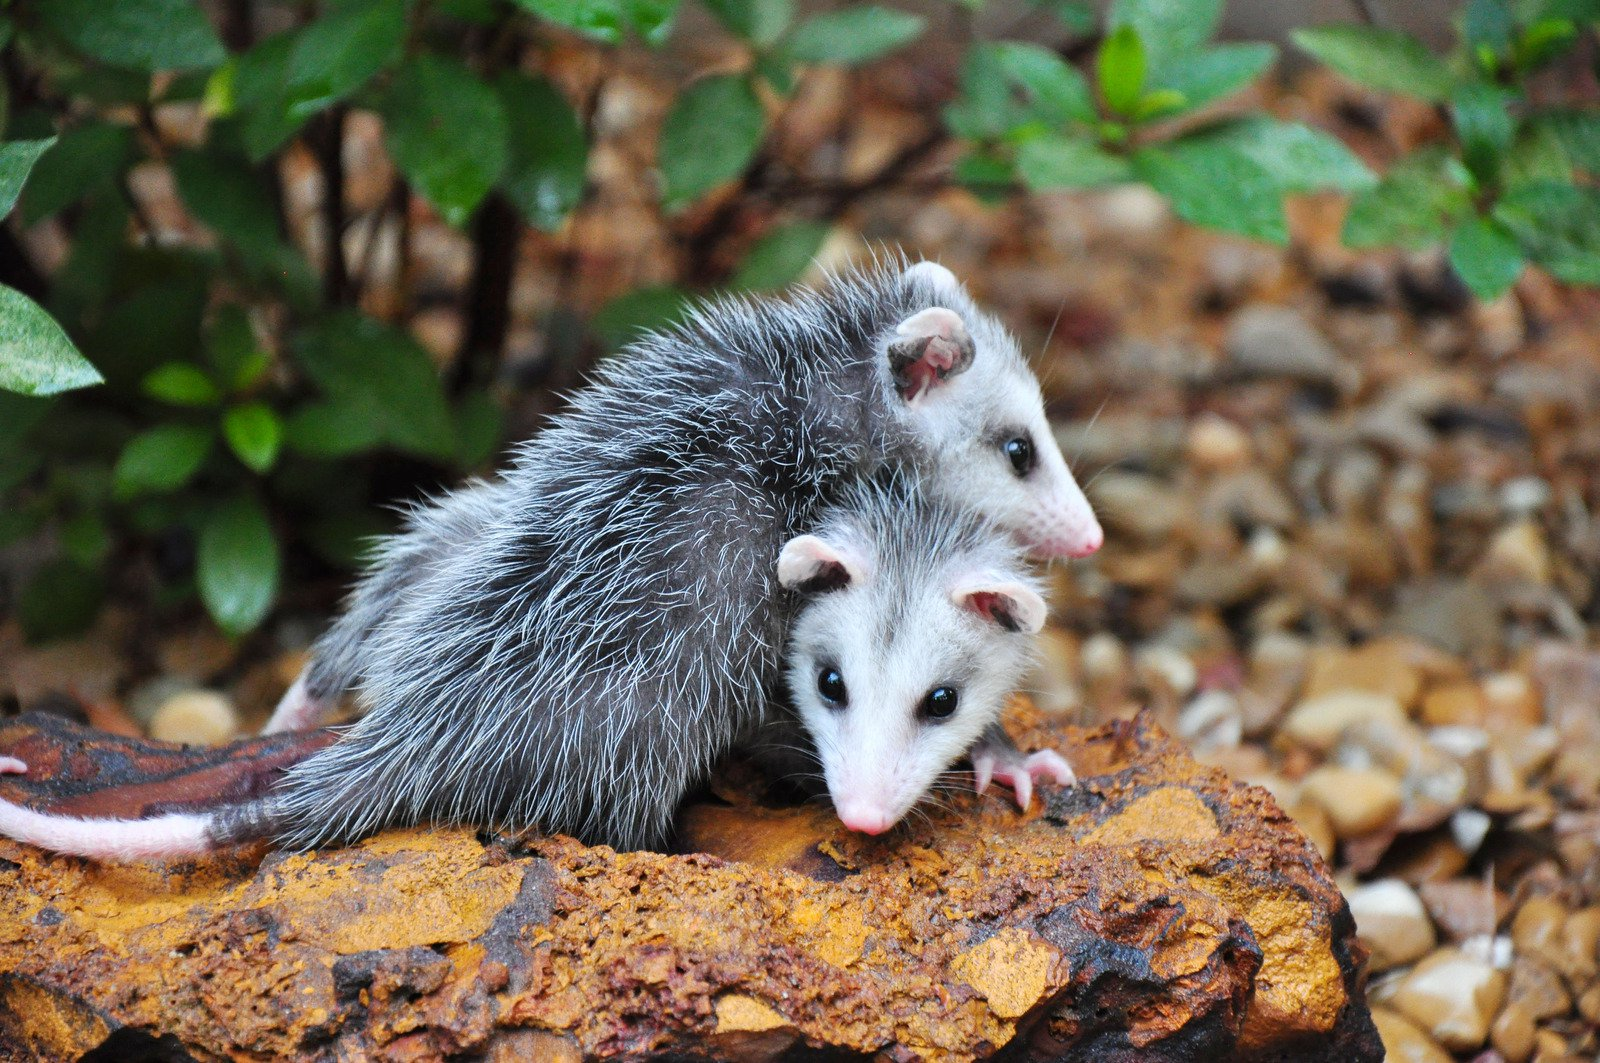

In [54]:
# Display image
example_id = 5
image = final_dataset["train"][example_id]["image"]
image

### Load a local ImageDataLoaders

In [32]:
from pathlib import Path
from fastai.vision.all import ImageDataLoaders, Resize, aug_transforms

In [33]:
path = Path(image_dir)

# Create the DataLoaders
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
)

In [34]:
print(f"Training set size: {len(dls.train_ds)}")
print(f"Validation set size: {len(dls.valid_ds)}")
print(f"Total dataset size: {len(dls.train_ds) + len(dls.valid_ds)}")

Training set size: 4320
Validation set size: 1080
Total dataset size: 5400


In [37]:
# Print the total number of classes in the dataset
print("Number of Classes:", len(dls.vocab))

# Display the list of class names
dls.vocab

Number of Classes: 90


['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']

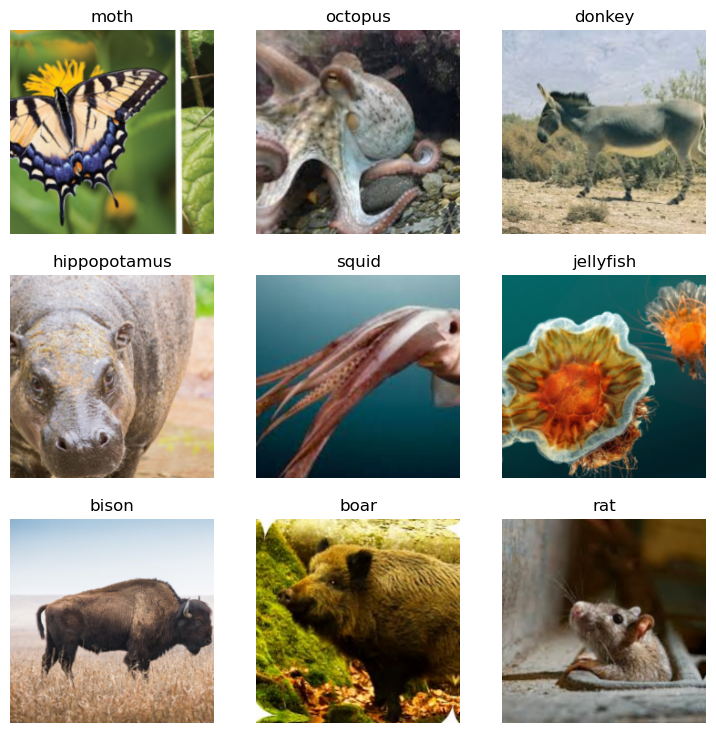

In [55]:
dls.show_batch()

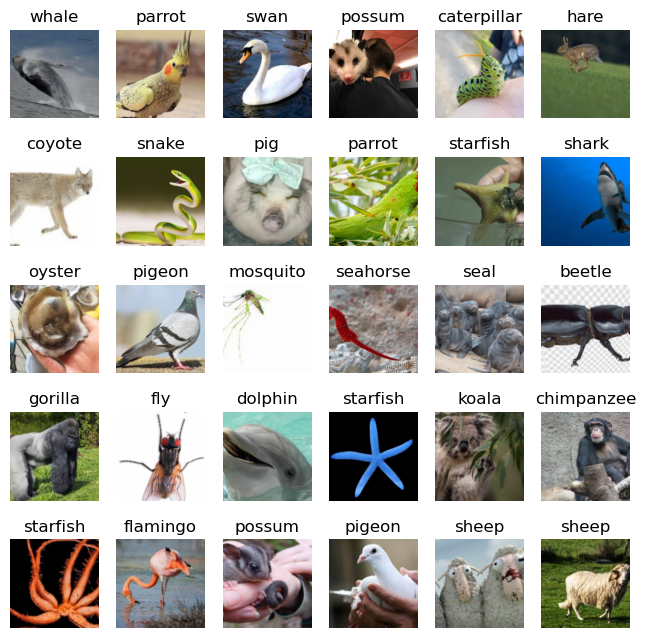

In [56]:
dls.show_batch(max_n=30, figsize=(8,8))